In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv('PP13_ISP22_timeseries.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print("Первые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())

Первые 5 строк:
        date  monthly_sales
0 2021-01-31       95799.45
1 2021-02-28      107537.77
2 2021-03-31      110276.15
3 2021-04-30      118061.86
4 2021-05-31      118234.89

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           36 non-null     datetime64[ns]
 1   monthly_sales  36 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 708.0 bytes
None


In [12]:
print("\nПропуски:", df.isnull().sum().sum())
# Данные полные, пропусков нет


Пропуски: 0


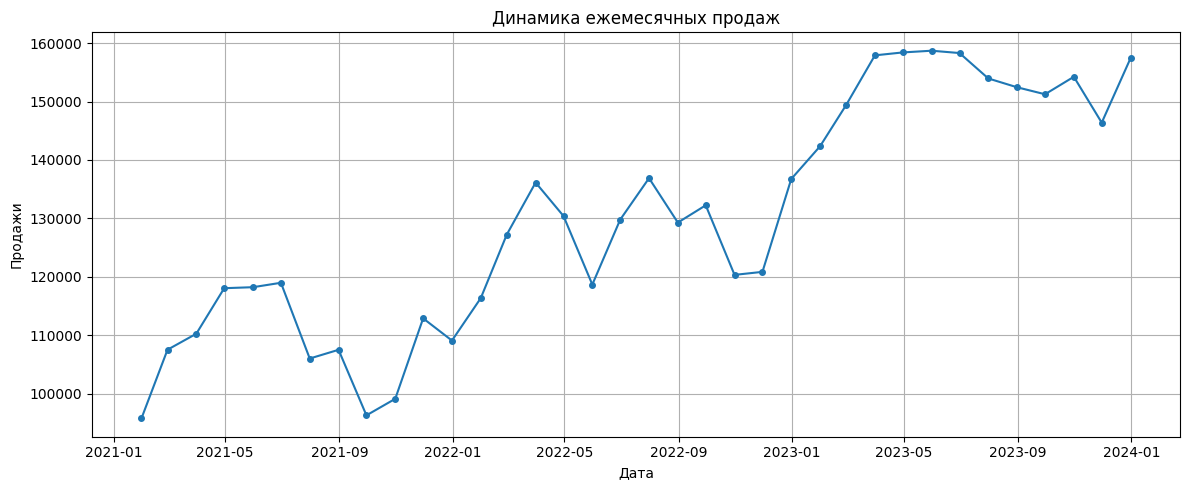

In [13]:
plt.figure(figsize=(12,5))
plt.plot(df['date'], df['monthly_sales'], marker='o', linestyle='-', markersize=4)
plt.title('Динамика ежемесячных продаж')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.grid(True)
plt.tight_layout()
plt.savefig('sales_dynamics.png', dpi=150)
plt.show()

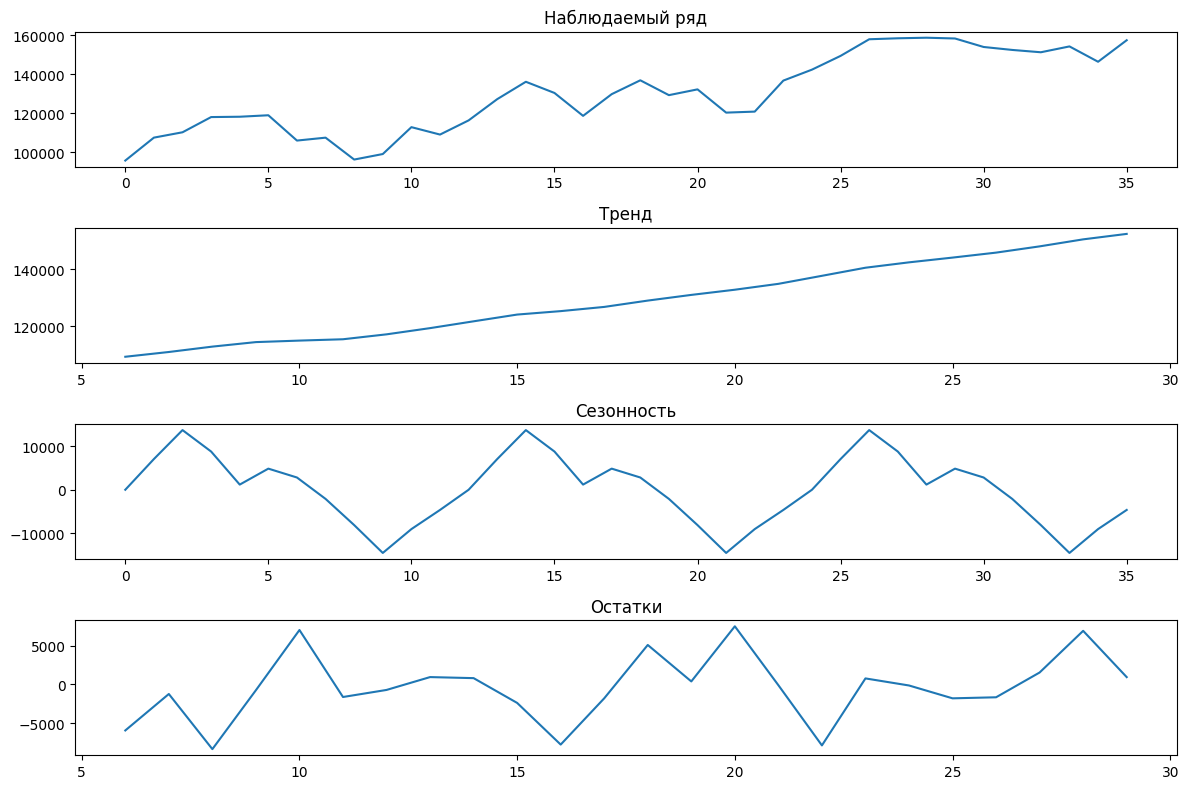

In [14]:
# Разложим ряд на компоненты (аддитивная модель)
decomposition = seasonal_decompose(df['monthly_sales'], model='additive', period=12)
fig, axes = plt.subplots(4,1, figsize=(12,8))
decomposition.observed.plot(ax=axes[0], title='Наблюдаемый ряд')
decomposition.trend.plot(ax=axes[1], title='Тренд')
decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
decomposition.resid.plot(ax=axes[3], title='Остатки')
plt.tight_layout()
plt.savefig('seasonal_decompose.png', dpi=150)
plt.show()
# Вывод: явно выражена сезонность с периодом 12 месяцев и растущий тренд

In [15]:
df['time'] = np.arange(len(df))
# Добавим месяцы как категориальный признак для учёта сезонности
df['month'] = df['date'].dt.month

In [16]:
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train_time = train[['time']]
y_train = train['monthly_sales']
X_test_time = test[['time']]
y_test = test['monthly_sales']

In [17]:
# Модель 1: Линейная регрессия (только тренд)
lr = LinearRegression()
lr.fit(X_train_time, y_train)
y_pred_lr = lr.predict(X_test_time)

In [18]:
# Модель 2: Полиномиальная регрессия 3-й степени + месяцы (для сезонности)
# Создадим матрицу признаков: time, time^2, time^3, month
train['time2'] = train['time']**2
train['time3'] = train['time']**3
test['time2'] = test['time']**2
test['time3'] = test['time']**3

features = ['time', 'time2', 'time3', 'month']
X_train_poly = train[features]
X_test_poly = test[features]

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)

In [20]:
# Модель 3: ARIMA (автоматический подбор порядка)
# Используем весь ряд для обучения ARIMA (лучше для прогноза на будущее)
# Но для честного сравнения обучим на train и предскажем на test
# ARIMA требует временной индекс
train_arima = train.set_index('date')['monthly_sales']
test_arima = test.set_index('date')['monthly_sales']

# Подберём параметры (p,d,q) по AIC на обучающем ряде
# Для простоты возьмём d=1 (убираем тренд), p=2, q=2 (можно уточнить)
best_aic = np.inf
best_order = None
# Перебор небольшой сетки для демонстрации
for p in range(0,3):
    for d in range(0,2):
        for q in range(0,3):
            try:
                model = ARIMA(train_arima, order=(p,d,q))
                res = model.fit()
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p,d,q)
            except:
                continue
print(f"Лучший порядок ARIMA: {best_order} с AIC={best_aic:.2f}")

# Обучим ARIMA с лучшим порядком
arima_model = ARIMA(train_arima, order=best_order)
arima_fitted = arima_model.fit()
# Прогноз на тестовый период
y_pred_arima = arima_fitted.forecast(steps=len(test_arima))

Лучший порядок ARIMA: (1, 1, 0) с AIC=566.66


In [21]:
def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{model_name}:")
    print(f"  MAE  = {mae:.2f}")
    print(f"  MSE  = {mse:.2f}")
    print(f"  RMSE = {rmse:.2f}")
    print(f"  MAPE = {mape:.2f}%")
    print()
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape}

results = {}
results['Linear Regression'] = evaluate(y_test, y_pred_lr, 'Linear Regression')
results['Poly+Season'] = evaluate(y_test, y_pred_poly, 'Poly+Season')
# ARIMA прогноз возвращает Series, приведём к numpy для единообразия
y_pred_arima_np = np.array(y_pred_arima)
results['ARIMA'] = evaluate(y_test, y_pred_arima_np, 'ARIMA')


Linear Regression:
  MAE  = 5207.28
  MSE  = 45060609.61
  RMSE = 6712.72
  MAPE = 3.38%

Poly+Season:
  MAE  = 21080.23
  MSE  = 624015999.95
  RMSE = 24980.31
  MAPE = 13.83%

ARIMA:
  MAE  = 4442.96
  MSE  = 34244801.91
  RMSE = 5851.91
  MAPE = 2.95%



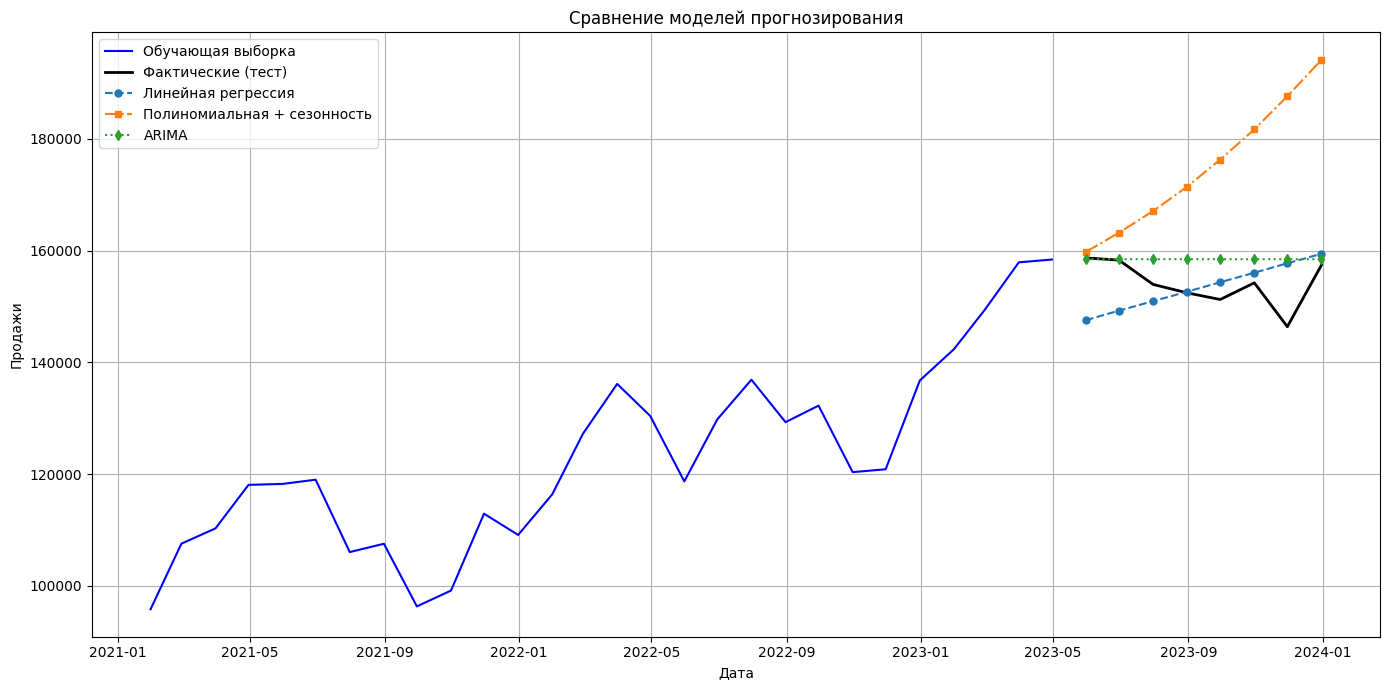

In [22]:
plt.figure(figsize=(14,7))
plt.plot(train['date'], train['monthly_sales'], label='Обучающая выборка', color='blue')
plt.plot(test['date'], test['monthly_sales'], label='Фактические (тест)', color='black', linewidth=2)
plt.plot(test['date'], y_pred_lr, label='Линейная регрессия', linestyle='--', marker='o', markersize=5)
plt.plot(test['date'], y_pred_poly, label='Полиномиальная + сезонность', linestyle='-.', marker='s', markersize=5)
plt.plot(test['date'], y_pred_arima_np, label='ARIMA', linestyle=':', marker='d', markersize=5)
plt.title('Сравнение моделей прогнозирования')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150)
plt.show()

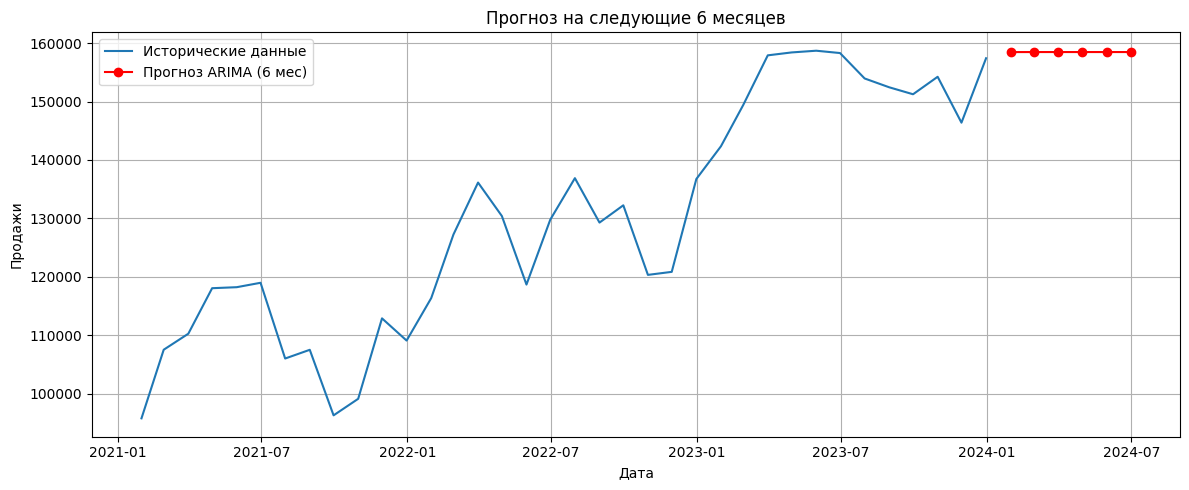

Прогноз на следующие 6 месяцев:
                 date       forecast
2023-05-31 2024-01-31  158452.353110
2023-06-30 2024-02-29  158459.165111
2023-07-31 2024-03-31  158459.962240
2023-08-31 2024-04-30  158460.055519
2023-09-30 2024-05-31  158460.066434
2023-10-31 2024-06-30  158460.067711


In [23]:
last_date = df['date'].max()
future_steps = 6
future_forecast = arima_fitted.forecast(steps=future_steps)
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=future_steps, freq='M')
future_df = pd.DataFrame({'date': future_dates, 'forecast': future_forecast})

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['monthly_sales'], label='Исторические данные')
plt.plot(future_df['date'], future_df['forecast'], label='Прогноз ARIMA (6 мес)', color='red', marker='o')
plt.title('Прогноз на следующие 6 месяцев')
plt.xlabel('Дата')
plt.ylabel('Продажи')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150)
plt.show()

print("Прогноз на следующие 6 месяцев:")
print(future_df)